In [12]:
#the wing we are designing is bounded by 3 criterion based upon the wind tunnel available,
#the max velocity we can achieve is around 40 m/s and our wind tunnel section has a width of
#1600 mm or 1.6 meters to achieve an aspect ratio similar to the goland wing of 12 we will 
#also have a chord constraint to scale relative to our span, the goland wing is roughly 6.1 
#metres by 1.8 metres

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

u_inf = 1.
alpha_deg = 2.  # Define angle of attack for static aeroelastic analysis.
rho = 1.02      # Air density. #inquire about this for our wind tunnel

M = 16             # Number of chordwise panels
N = 32             # Number of spanwise panels
M_star_fact = 10   # Length of the wake in chords.
num_modes =  8     # Number of vibration modes retained in the structural model.

c_ref = .2 
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

case_name = 'mycase6'
route_test_dir = os.path.abspath('')

print('The case to run will be: %s' % case_name)
print('Case files will be saved in ./cases/%s' %case_name)
print('Output files will be saved in ./output/%s/' %case_name)

#let us assume we are making a wing that is half the size, thus let us set our b_ref to 1.2 metres
#to achieve an aspect ratio of 12 we need 2*1.2/x = 12 leading to our chord of 0.2 metres

#the elastic axis is at 0.33 chord and the main cg is at 0.43 chord as per the goland wing
ws = wings.Goland(M=M,
                  N=N,
                  Mstar_fact=M_star_fact,
                  u_inf=u_inf,
                  alpha=alpha_deg,
                  rho=rho,
                  b_ref=2. * 1.2,
                  main_chord= 0.2,
                  aspect_ratio=(2. * 1.2) / 0.2,
                  sweep=0,
                  physical_time=2,
                  n_surfaces=2,
                  route = route_test_dir + '/cases',
                  case_name=case_name
                  )

def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    width = 100E-3
    height = 3E-3
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = 1.304 #7
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    #implement lumped masses

    n_lumped_mass = 4
    self.lumped_mass = np.zeros((n_lumped_mass))
    self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
    self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
    self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

    #actuator itself
    self.lumped_mass[2] = .074
    self.lumped_mass_position[2] = np.array([0, 0, 0])
    self.lumped_mass_nodes[2] = self.N//2
    self.lumped_mass_inertia[2, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.lumped_mass[3] = .074
    self.lumped_mass_position[3] = np.array([0, 0, 0])
    self.lumped_mass_nodes[3] = self.N // 2 + 1
    self.lumped_mass_inertia[3, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    massweight = .4
    extended = True
    #unextended
    if not extended:
        self.lumped_mass[0] = massweight
        self.lumped_mass_position[0] = np.array([-.05, 0, 0])
        self.lumped_mass_nodes[0] = self.N//2
        self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

        self.lumped_mass[1] = massweight
        self.lumped_mass_position[1] = np.array([-.05, 0, 0])
        self.lumped_mass_nodes[1] = self.N // 2 + 1
        self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    #extended
    if extended:
        self.lumped_mass[0] = massweight
        self.lumped_mass_position[0] = np.array([-.15, 0, 0])
        self.lumped_mass_nodes[0] = self.N//2
        self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

        self.lumped_mass[1] = massweight
        self.lumped_mass_position[1] = np.array([-.15, 0, 0])
        self.lumped_mass_nodes[1] = self.N // 2 + 1
        self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    print(self.lumped_mass_nodes)

ws.update_mass_stiff = new_update_mass_stiff.__get__(ws, wings.Goland)   

ws.clean_test_files()
ws.update_derived_params()
ws.set_default_config_dict()

ws.generate_aero_file()
ws.generate_fem_file()

The case to run will be: mycase6
Case files will be saved in ./cases/mycase6
Output files will be saved in ./output/mycase6/
2.2500000000000002e-10
2.500000000000001e-07
[[2.0700e+07 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 7.8000e+06 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 7.8000e+06 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 4.6800e+01 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.5525e+01 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.7250e+04]]
2.502250000000001e-07
0.0006756075000000003
[16 17 16 17]


In [13]:
ws.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': ws.case_name, 'route': ws.route,
    'write_screen': 'on', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': ws.case_name + '.log'}

ws.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': ws.quat}

ws.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': ws.Mstar_fact * ws.M,
    'freestream_dir': ws.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': ws.u_inf,
                                    'u_inf_direction': ws.u_inf_direction,
                                    'dt': ws.dt}}

ws.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': ws.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': ws.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': ws.u_inf,
            'u_inf_direction': ws.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

ws.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

ws.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

ws.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

ws.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': ws.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': num_modes,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': ws.dt,
                                                      'ScalingDict': {'length': 0.5 * ws.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': ws.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

ws.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 40, 81],
                                   'modes_to_plot': []}
                                    

ws.config.write()
                            

In [14]:
sharpy_output = sharpy.sharpy_main.main(['', ws.route + ws.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/password/sharpy/sharpy
SHARPy being run is in /home/password/.local/lib/python3.10/site-packages
SHARPy output folder set
	/home/password/sharpy/sharpy/output//

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   |  1.3956  | -0.0007  | -39.9359 |  0.9272  |  5.2552  |  0.0324  |
|  1  |  0  |  -5.25115  |  1.3944  | -0.0009  | -39.9136 |  0.9277  |  5.2559  |  0.0324  |
|  2  |  0  |  -8.84347  |  1.3944  | -0.0009  | -39.9136 |  0.9277  |  5.2559  |  0.0324  |
|  3  |  0  | -11.88467  |  1.3944  | -0.0009  | -39.9136 |  0.9277  |  5.2559  |  0.0324  |
Generating an instance of AerogridPlot
Variable include_forward_motion has no assigned value in the settings file.
    will default to the value: False
Variable include_unsteady_applied_forces has no assigned value in the settings file.
    will default to the value: False
Variable name_prefix has no assigned value in the settings file.
    will default to the value: 
Variable u_inf has no assigned value in the settings file.
    will default to the value: 0.0
Variable dt has no assigned value in the settings file.
    will default to the value: 0.0
Variable include_velocities has no assigned value in the settings file.


/home/password/.local/lib/python3.10/site-packages/sharpy/solvers/modal.py:289: RuntimeWarning:

invalid value encountered in sqrt



|      0       |   0.000000   |   5.492170   |   0.874106   |   0.874106   |  -0.000000   |   1.144026   |
|      1       |   0.000000   |   6.453973   |   1.027182   |   1.027182   |  -0.000000   |   0.973538   |
|      2       |   0.000000   |  29.862518   |   4.752767   |   4.752767   |  -0.000000   |   0.210404   |
|      3       |   0.000000   |  41.648268   |   6.628528   |   6.628528   |  -0.000000   |   0.150863   |
|      4       |   0.000000   |  60.361081   |   9.606764   |   9.606764   |  -0.000000   |   0.104093   |
|      5       |   0.000000   |  85.298536   |  13.575684   |  13.575684   |  -0.000000   |   0.073661   |
|      6       |   0.000000   |  90.157717   |  14.349046   |  14.349046   |  -0.000000   |   0.069691   |
|      7       |   0.000000   |  129.763270  |  20.652466   |  20.652466   |  -0.000000   |   0.048420   |
|      8       |   0.000000   |  163.760274  |  26.063257   |  26.063257   |  -0.000000   |   0.038368   |
|      9       |   0.000000   |  172.

...

	state-space model produced in form:
			h_{n+1} = A h_{n} + B u_{n}
			with:
	x_n = h_n + Bp u_n
			...done in 13.94 sec
Scaling UVLM system with reference time 0.914400s
Non-dimensional time step set (0.013670)
System scaled in 19.818601s
Generating an instance of LinearBeam
Variable remove_rigid_states has no assigned value in the settings file.
    will default to the value: False
Warning, projecting system with damping onto undamped modes


/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning:

Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.

/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:1217: RuntimeWarning:

invalid value encountered in sqrt




Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -197.31 125.34 1.00
Node  1 	-> B -0.000 -0.116 0.006
			-> A 0.116 0.075 0.003
			-> G 0.116 0.075 -0.001
	Node mass:
		Matrix: 0.1043
Node  2 	-> B -0.001 -0.116 0.011
			-> A 0.116 0.150 0.001
			-> G 0.116 0.150 -0.003
	Node mass:
		Matrix: 0.0522
Node  3 	-> B -0.002 -0.116 0.015
			-> A 0.116 0.224 -0.006
			-> G 0.116 0.224 -0.010
	Node mass:
		Matrix: 0.1043
Node  4 	-> B -0.004 -0.116 0.019
			-> A 0.116 0.298 -0.016
			-> G 0.115 0.298 -0.020
	Node mass:
		Matrix: 0.0522
Node  5 	-> B -0.005 -0.116 0.022
			-> A 0.116 0.371 -0.030
			-> G 0.115 0.371 -0.034
	Node mass:
		Matrix: 0.1043
Node  6 	-> B -0.007 -0.116 0.025
			-> A 0.116 0.443 -0.047
			-> G 0.114 0.443 -0.051
	Node mass:
		Matrix: 0.0522
Node  7 	-> B -0.008 -0.115 0.027
			-> A 0.115 0.515 -0.067
			-> G 0.113 0.515 -0.071
	Node mass:
		Matrix: 0.1043
Node  8 	-> B -0.009 -0.115 0.029
			-> A 0.115 0.586 -0.088
			-> G 0.112 0.586 -0.092
	Node mass:
		Matrix:

/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning:

Reduced Order Model Unstable



LTI	u: 11.50 m/2	max. CT eig. real: 17.764118	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	77.22	77.22
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 11.88 m/2	max. CT eig. real: 18.343383	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	79.74	79.74
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 12.25 m/2	max. CT eig. real: 18.922648	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	82.26	82.26
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 12.62 m/2	max. CT eig. real: 19.501912	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	84.78	84.78
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 13.00 m/2	max. CT eig. real: 20.081177	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	87.30	87.30
Updating C and K matrices and natural frequencies with new

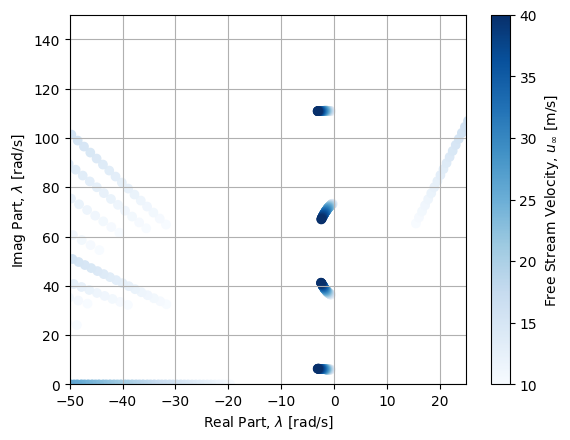

In [15]:
file_name = './output/%s/stability/velocity_analysis_min0100_max0400_nvel0081.dat' % case_name
%matplotlib inline
velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 25)
plt.ylim(0, 150)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

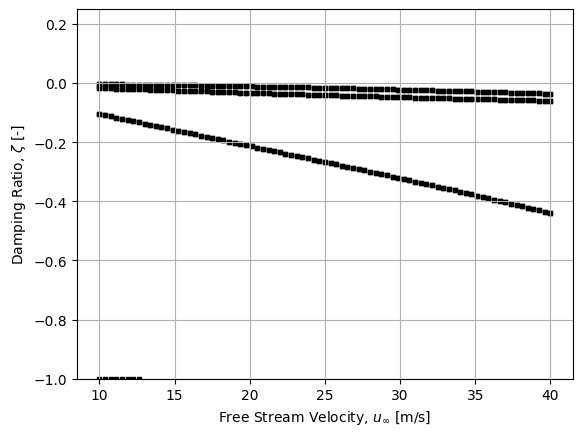

In [16]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)

plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

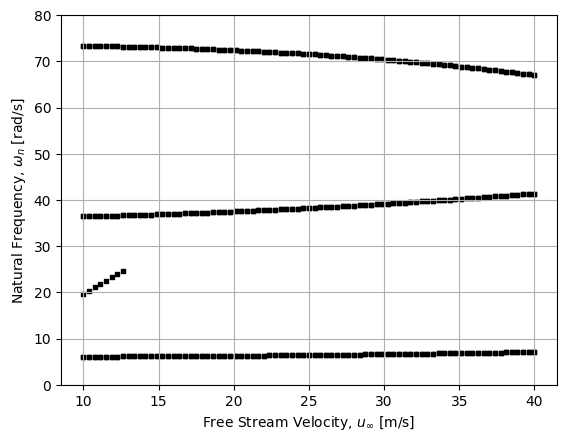

In [17]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
plt.grid()
plt.ylim(0, 80)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');

In [18]:
import h5py
file_path = './cases/mycase6.fem.h5'  # Replace with your file path

import plotly.graph_objects as go

# Open the .h5 file
file_path = './cases/mycase6.fem.h5'

with h5py.File(file_path, 'r') as h5_file:
    coordinates = h5_file['coordinates'][...]  # Shape: (33, 3)
    connectivities = h5_file['connectivities'][...]  # Shape: (16, 3)
    lumped_mass_nodes = h5_file['lumped_mass_nodes'][...]  # Shape: (2,)
    lumped_mass_position = h5_file['lumped_mass_position'][...]  # Shape: (2, 3)

# Plot beams as lines
beam_lines = []
for conn in connectivities:
    node_coords = coordinates[conn]
    beam_lines.append(go.Scatter3d(
        x=node_coords[:, 0],
        y=node_coords[:, 1],
        z=node_coords[:, 2],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Beam'
    ))

# Plot lumped masses as scatter points
lumped_mass_points = go.Scatter3d(
    x=[coordinates[node_idx, 0] + lumped_mass_position[i, 0] for i, node_idx in enumerate(lumped_mass_nodes)],
    y=[coordinates[node_idx, 1] + lumped_mass_position[i, 1] for i, node_idx in enumerate(lumped_mass_nodes)],
    z=[coordinates[node_idx, 2] + lumped_mass_position[i, 2] for i, node_idx in enumerate(lumped_mass_nodes)],
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Lumped Mass'
)

print(lumped_mass_points)

# Combine beams and lumped masses into one figure
fig = go.Figure(data=beam_lines + [lumped_mass_points])

# Set layout for 3D visualization
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
    ),
    title="Interactive 3D Plot of Beam Structure and Lumped Masses"
)

fig.show()

Scatter3d({
    'marker': {'color': 'red', 'size': 6},
    'mode': 'markers',
    'name': 'Lumped Mass',
    'x': [-0.15, -0.15, 0.0, 0.0],
    'y': [1.2, -1.2, 1.2, -1.2],
    'z': [0.0, 0.0, 0.0, 0.0]
})


In [19]:
wake_length = 50
chord = 0.2
num_chord_panels = M
WSP = 20
dt = chord/num_chord_panels/WSP
wake_panels = int(wake_length*chord/dt)
pu.plot_timestep(sharpy_output, tstep=-1, minus_mstar=(wake_panels - 6), plotly=True, custom_scaling=False, z_compression=0.5).update_layout(scene=dict(aspectmode='data')).show()


6.666666666666668e-11
42.98761028030032


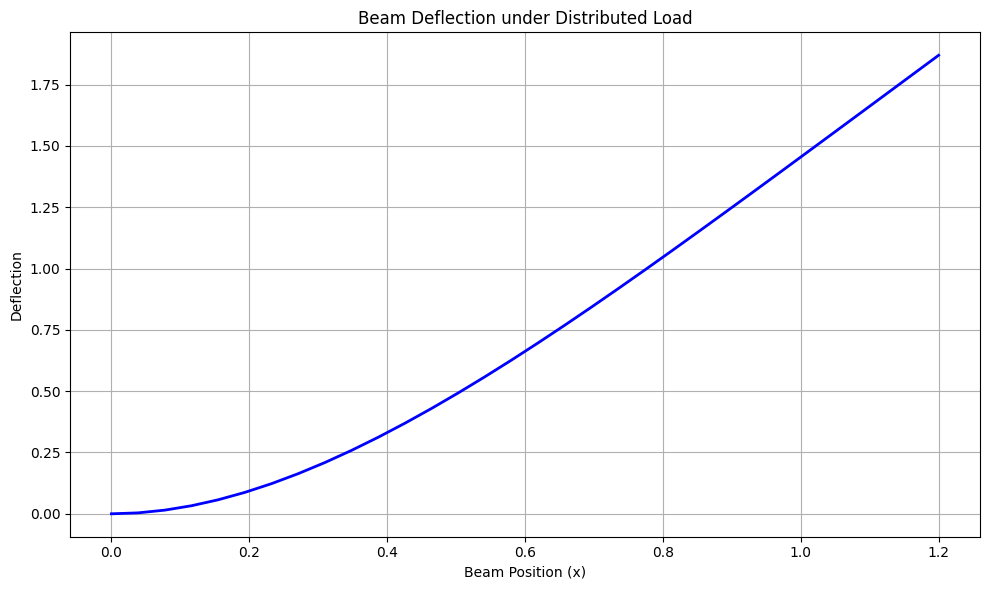

In [20]:
import numpy as np

# Constants
rho = 1.225  # air density (kg/m^3) at atmospheric conditions
V = 40 # velocity (m/s)
chord = 0.2  # chord length (m)
span = 1.2  # span (m)
width = 0.1  # beam width (m)
height = 0.002  # beam height (m)
E = 69e9  # Young's modulus for aluminum (Pa)
I = (width * height**3) / 12  # moment of inertia (m^4)
print(I)
CL = 2*np.pi  # Adjusted lift coefficient for NACA 0012 at 2 degrees AoA
aoa = np.radians(2)  # angle of attack in radians

# Aerodynamic forces
q = 0.5 * rho * V**2  # dynamic pressure (Pa)
L_per_span = q * CL * aoa * chord  # lift per unit span (N/m)
print(L_per_span)

# Beam deflection
x = np.linspace(0,span,N)
deflection = (((L_per_span - 9.81) * x**2) / (24 * E * I)) * (x**2 + 6 * span**2 - 4 * span * x)

plt.figure(figsize=(10, 6))
plt.plot(x, deflection, 'b-', linewidth=2)
plt.title('Beam Deflection under Distributed Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Deflection')
plt.grid(True)
plt.tight_layout()
plt.show()



25555555555.555553
1.4634666666666666e-09
2.17728
[0.011588429037581187, 0.011588429037581187, 0.011588429037581187, 0.011588429037581187]


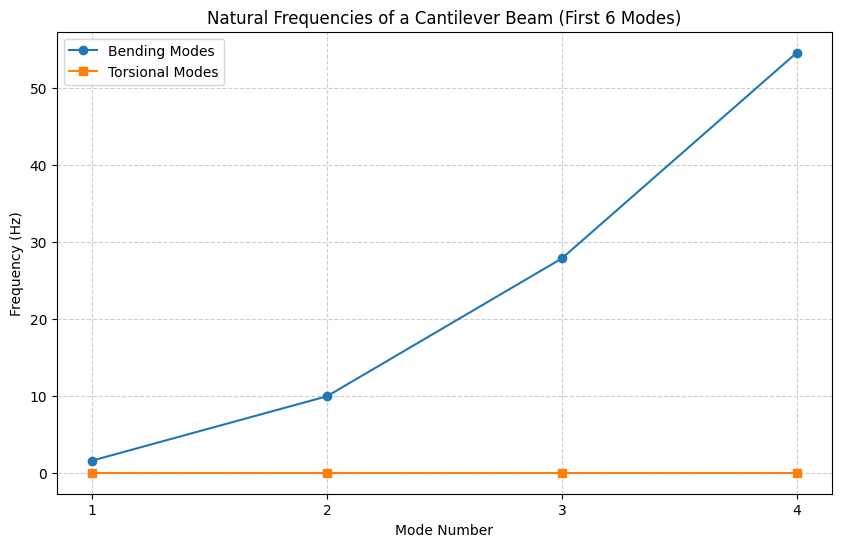

In [21]:

def bending_frequencies_cantilever(E, I, rho, A, L, num_modes=6):
    """
    Calculate bending natural frequencies of a cantilever beam.
    E: Young's modulus (Pa)
    I: Area moment of inertia (m^4)
    rho: Density (kg/m^3)
    A: Cross-sectional area (m^2)
    L: Length of the beam (m)
    num_modes: Number of bending modes to compute
    """
    # Extended mode shape constants for a cantilever beam (up to 4 modes)
    beta = [1.875, 4.694, 7.855, 10.996]
    beta = beta[:num_modes]
    
    frequencies = [
        (beta_n**2 / (2 * np.pi)) * np.sqrt(E * I / (rho * A * L**4))
        for beta_n in beta
    ]
    return frequencies

def torsional_frequencies_cantilever(G, J, I_p, rho, L, num_modes=4):
    """
    Calculate torsional natural frequencies of a cantilever beam.
    G: Shear modulus (Pa)
    J: Polar moment of inertia (m^4)
    I_p: Mass moment of inertia of the cross-section (kg·m^2)
    rho: Density (kg/m^3)
    L: Length of the beam (m)
    num_modes: Number of torsional modes to compute
    """
    # Torsional frequencies are generally mode-independent for simple beams
    base_frequency = (1 / (2 * np.pi)) * np.sqrt(G * J / (I_p * rho * L))
    frequencies = [base_frequency for _ in range(num_modes)]
    return frequencies

E = 69e9  # Young's modulus (Pa)
rho = 2700  # Density (kg/m^3)
L = 1.2  # Length (m)
b = 0.2  # Width (m)
h = 0.0028  # Height (m)
nu = 0.35  # Poisson's ratio

# Bending parameters
I = (b * h**3) / 12  # Area moment of inertia (m^4)
A = b * h  # Cross-sectional area (m^2)

# Torsion parameters
G = E / (2 * (1 + nu))  # Shear modulus (Pa)
J = (b * h**3) / 3  # Polar moment of inertia (m^4), approximation for rectangle
I_p = rho * A * L**2  # Approximation for mass moment of inertia

print(G)
print(J)
print(I_p)

# Compute frequencies
num_modes = 4
bending_modes = bending_frequencies_cantilever(E, I, rho, A, L, num_modes)
torsional_modes = torsional_frequencies_cantilever(G, J, I_p, rho, L, num_modes)

# Plotting
modes = range(1, num_modes + 1)
plt.figure(figsize=(10, 6))

plt.plot(modes, bending_modes, 'o-', label='Bending Modes')
plt.plot(modes, torsional_modes, 's-', label='Torsional Modes')

print(torsional_modes)

plt.xlabel('Mode Number')
plt.ylabel('Frequency (Hz)')
plt.title('Natural Frequencies of a Cantilever Beam (First 6 Modes)')
plt.xticks(modes)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

